Уравнение математического маятника
$$
\ddot{\theta}+\frac{g}{L}sin(\theta)=0
$$

$\theta(t)$ - угол отклонения маятника в момент $t$ от нижнего положения равновесия

$L$ - длина подвеса

$g$ - ускорение свободного падения

$m$ - масса маятника

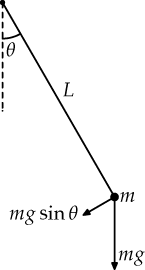

Для решения ДУ необходимо задать два начальных условия:

$\theta(t_0=0) = \theta_0$

$\dot{\theta}(t_0=0) = \dot{\theta}_0$

При малых углах отклонения:
$sin(\theta)\approx\theta$

И тогда уравнение примет вид:
$$
\ddot{\theta}+\frac{g}{L}\theta=0
$$

Обозначим: $\omega_0=\sqrt{\frac{g}{L}}$

Тогда: $$\ddot{\theta}+\omega_0^2\theta=0$$

Уравнение имеет аналитическое решение: $$\theta=C_1cos(\omega_0t)+C_2sin(\omega_0t)$$

$\theta(t_0=0)=\theta_0=C1$

$\dot{\theta}(t_0=0)=\dot{\theta_0}=C_2\omega_0$

Тогда:

$$\theta=\theta_0cos(\omega_0t)+\frac{\dot{\theta_0}}{\omega_0}sin(\omega_0t)$$

$$\dot{\theta}=-\theta_0\omega_0sin(\omega_0t)+\dot{\theta_0}cos(\omega_0t)$$

Полная энергия маятника: $E=E_п+E_k$

$E_п = mgL(1-cos(\theta))$

$E_k = \frac{mv^2}{2}$

$v = \omega L = \dot{\theta}L$

$E_k = \frac{m\omega^2L^2}{2}$

$E(\theta,\omega) = mgL(1-cos(\theta)) + \frac{m\omega^2L^2}{2}$


Метод Рунге-Кутты четвертого порядка

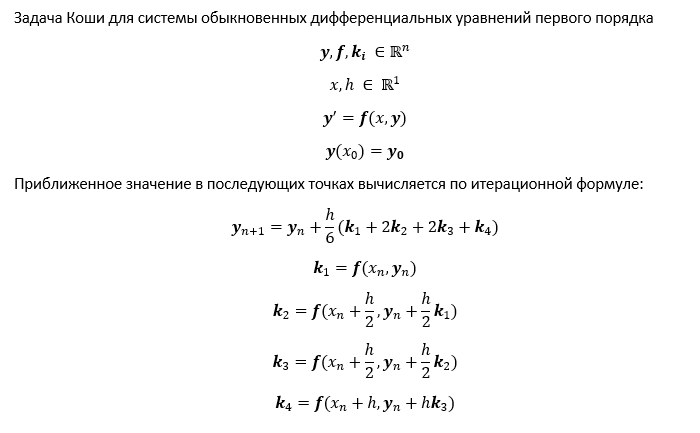

Метод Эйлера

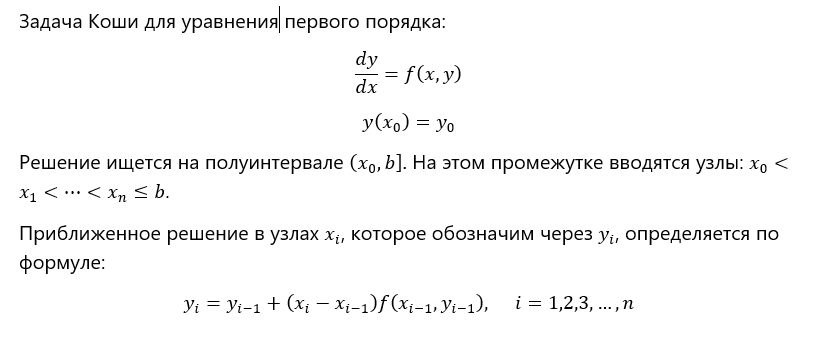

Переход от уравнения второго порядка к системе дифференциальных уравнений первого порядка

Произведем замену: $\dot{\theta}=\omega$

Тогда:
$$
\left\{\begin{matrix}
\dot{\theta}=\omega=f_1(t,\theta,\omega)
 \\
\dot{\omega}=-\frac{g}{L}sin(\theta)=f_2(t,\theta,\omega)
\end{matrix}\right.
$$

In [ ]:
#Импорт зависимостей
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from math import pi
from matplotlib.patches import Circle

In [ ]:
#Параметры задачи, начальные условия и временная сетка
g = 9.81
L = 1.0
m = 2

#Малые колебания
theta0 = pi/100
omega0 = 0.0

T = 10.0
dt = 0.01

t = np.arange(0, T, dt)
n = len(t)

In [ ]:
#Метод Рунге-Кутты четвертого порядка
def RK4(theta0, omega0, dt, n):
    theta = np.zeros(n)
    omega = np.zeros(n)
    theta[0] = theta0
    omega[0] = omega0
    for i in range(n-1):
        k1_omega = -(g/L)*np.sin(theta[i])
        k1_theta = omega[i]
        k2_omega = -(g/L)*np.sin(theta[i] + 0.5*dt*k1_theta)
        k2_theta = omega[i] + 0.5*dt*k1_omega
        k3_omega = -(g/L)*np.sin(theta[i] + 0.5*dt*k2_theta)
        k3_theta = omega[i] + 0.5*dt*k2_omega
        k4_omega = -(g/L)*np.sin(theta[i] + dt*k3_theta)
        k4_theta = omega[i] + dt*k3_omega
        theta[i+1] = theta[i] + (dt/6)*(k1_theta + 2*k2_theta + 2*k3_theta + k4_theta)
        omega[i+1] = omega[i] + (dt/6)*(k1_omega + 2*k2_omega + 2*k3_omega + k4_omega)
    return theta, omega

In [ ]:
#Метод Эйлера
def Euler(theta0, omega0, dt, n):
    theta = np.zeros(n)
    omega = np.zeros(n)
    theta[0] = theta0
    omega[0] = omega0
    for i in range(n-1):
        omega[i+1] = omega[i] - (g/L)*np.sin(theta[i])*dt
        theta[i+1] = theta[i] + omega[i]*dt
    return theta, omega

In [ ]:
#Аналитическое решение (малые колебания)
def Analytic(theta0, omega0, t):
    omega_0 = np.sqrt(g/L)
    theta_analytical = theta0*np.cos(omega_0*t) + (omega0/omega_0)*np.sin(omega_0*t)
    omega_analytical = -theta0*omega_0*np.sin(omega_0*t)+omega0*np.cos(omega_0*t)
    return theta_analytical, omega_analytical

In [ ]:
#Функция полной энергии маятника
def Energy(theta, omega):
    U = m*g*L*(1 - np.cos(theta))
    K = 0.5*m*(L**2)*(omega**2)
    return U + K

In [ ]:
#Получение решений
theta_euler, omega_euler = Euler(theta0, omega0, dt, n)
theta_rk4, omega_rk4 = RK4(theta0, omega0, dt, n)
theta_analytical, omega_analytical = Analytic(theta0, omega0, t)

In [ ]:
#Построение графиков
plt.figure(figsize=(12, 8))

# Траектория
plt.subplot(2, 3, 1)
plt.plot(t, theta_euler, label='Метод Эйлера')
plt.plot(t, theta_rk4, label='RK4')
plt.plot(t, theta_analytical, label='Аналитическое решение', linestyle='--')
plt.xlabel('Время t, c')
plt.ylabel(r'$\theta(t)$, рад')
plt.legend()
plt.title('Траектория')

# Фазовый портрет
plt.subplot(2, 3, 2)
plt.plot(theta_euler, omega_euler, label='Метод Эйлера')
plt.plot(theta_rk4, omega_rk4, label='RK4', lw=3)
plt.plot(theta_analytical, omega_analytical, label='Аналитическое решение', linestyle = '--')
plt.xlabel(r'Угол $\theta$, рад')
plt.ylabel(r'Угловая скорость $\omega$, рад/с')
plt.legend()
plt.title('Фазовый портрет')

# Энергия
energy_euler = Energy(theta_euler, omega_euler)
energy_rk4 = Energy(theta_rk4, omega_rk4)
energy_analytic = Energy(theta_analytical, omega_analytical)
plt.subplot(2, 3, 3)
plt.plot(t, energy_euler, label='Метод Эйлера')
plt.plot(t, energy_rk4, label='RK4')
plt.plot(t, energy_analytic, label='Аналитическое решение', linestyle ='--')
plt.xlabel('Время t, с')
plt.ylabel('Энергия E, Дж')
plt.legend()
plt.title('Полная энергия')

# Ошибка по координате
error_euler = np.abs(theta_euler - theta_analytical)
error_rk4 = np.abs(theta_rk4 - theta_analytical)
plt.subplot(2, 3, 4)
plt.plot(t, error_euler, label='Ошибка в методе Эйлера')
plt.plot(t, error_rk4, label='Ошибка RK4')
plt.xlabel('Время t, c')
plt.ylabel(r'Ошибка $\Delta\theta$, рад')
plt.legend()
plt.title(r'Накопление ошибки по координате $\theta$')

# Ошибка по энергии
energy_error_euler = np.abs(Energy(theta_euler, omega_euler) - Energy(theta_analytical, omega_analytical))
energy_error_rk4 = np.abs(Energy(theta_rk4, omega_rk4) - Energy(theta_analytical, omega_analytical))
plt.subplot(2, 3, 5)
plt.plot(t, energy_error_euler, label='Ошибка в методе Эйлера')
plt.plot(t, energy_error_rk4, label='Ошибка RK4')
plt.xlabel('Время t, c')
plt.ylabel(r'Ошибка $\Delta$E, Дж')
plt.legend()
plt.title(r'Накопление ошибки по энергии')

plt.tight_layout()
plt.show()

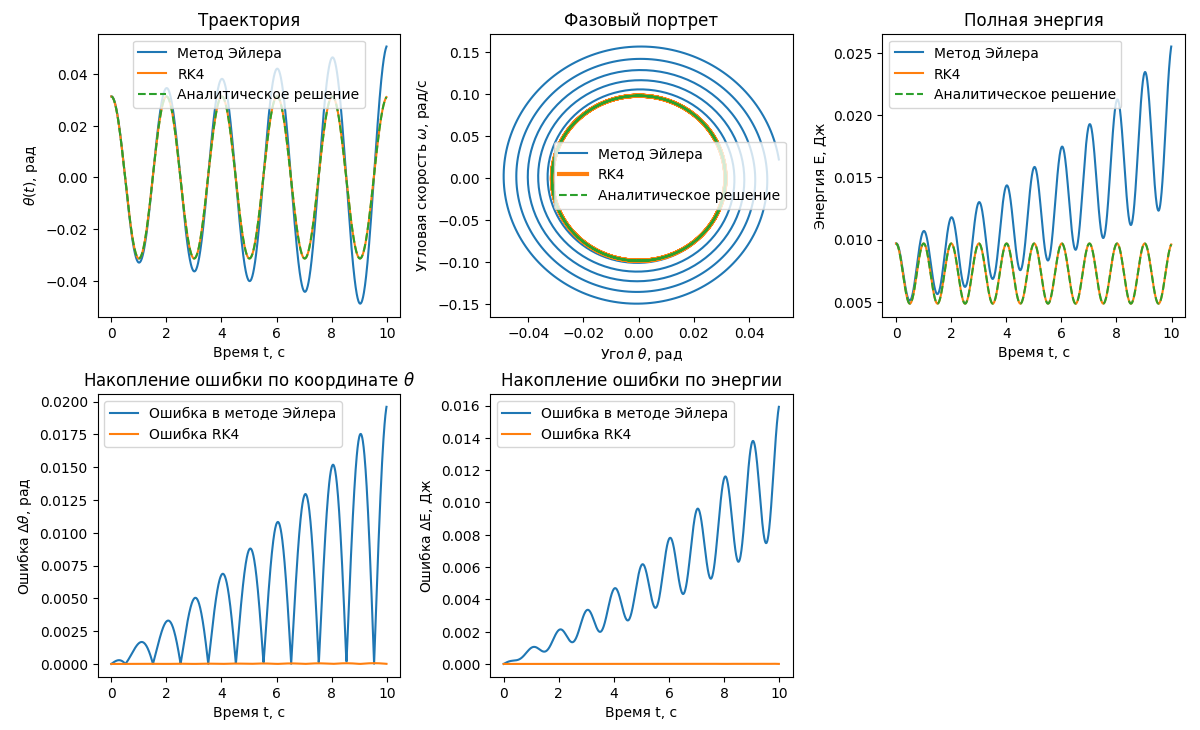

Построим фазовые потреты при различных значениях начальных углов колебаний:
$\theta_0 = \frac{\pi}{6},\frac{\pi}{3},\frac{\pi}{2},\frac{2\pi}{3} $

In [ ]:
# Фазовые портреты для разных начальных условий
initial_conditions = [(pi/6, 0), (pi/3, 0), (pi/2, 0), (2*pi/3, 0)]
plt.figure(figsize=(10, 8))

for i, (theta0, omega0) in enumerate(initial_conditions):
    theta, omega = RK4(theta0, omega0, dt, n)
    plt.plot(theta, omega, label=r'$\theta_0$'+f'={theta0:.2f}, рад')

plt.xlabel(r'Угол $\theta$, рад')
plt.ylabel(r'Угловая скорость $\omega$, рад/с')
plt.legend()
plt.title('Фазовые портреты')
plt.grid()
plt.show()

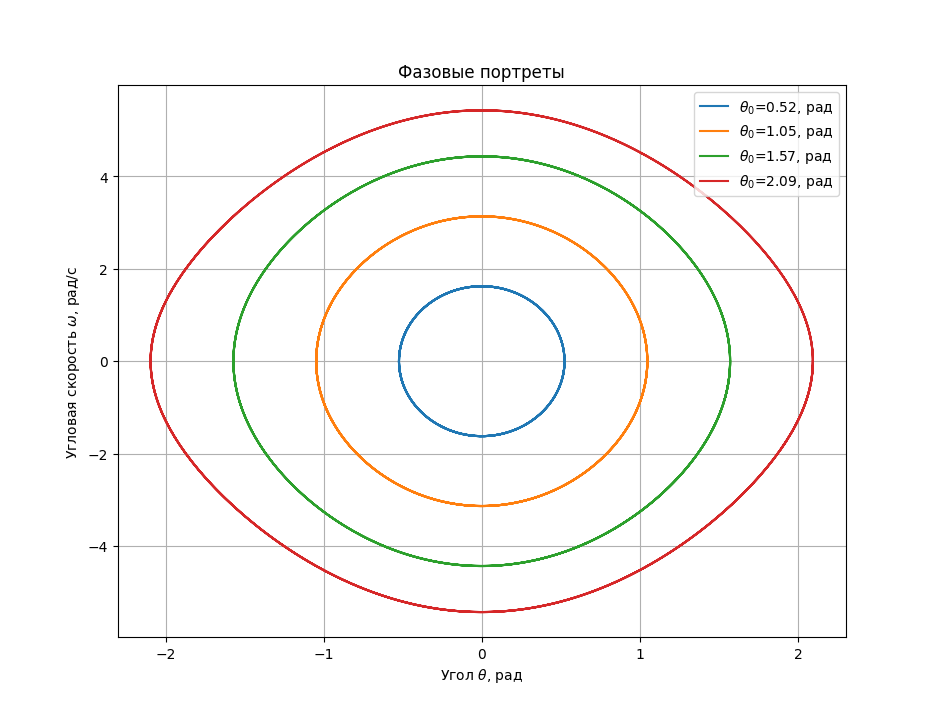

In [ ]:
#Анимация маятника
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-L*1.2, L*1.2)
ax.set_ylim(-L*1.2, L*1.2)
line, = ax.plot([], [], 'o-', lw=2)

def animate(i):
    x = [0, L*np.sin(theta_rk4[i])]
    y = [0, -L*np.cos(theta_rk4[i])]
    line.set_data(x, y)
    return line,

ani = FuncAnimation(fig, animate, frames=n, interval=20, blit=True)
plt.title(f'Колеблющийся маятник\n L = {L}')
plt.grid()
plt.show()

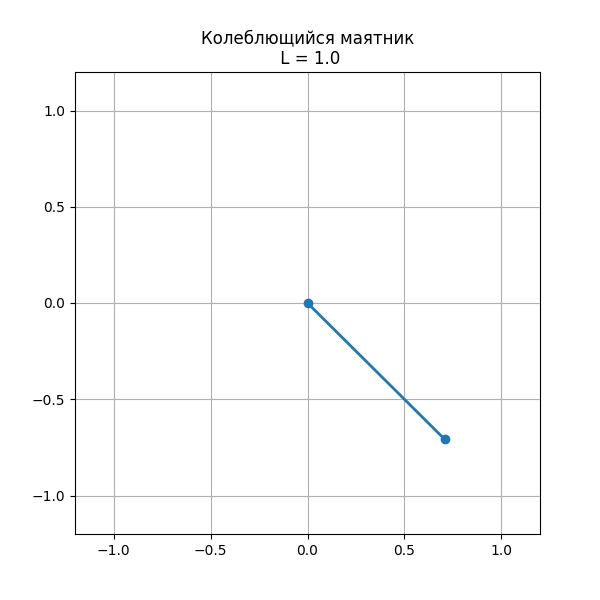

Смоделируем и визуализируем систему из 3 математических маятников, для которых длины

$L_1 = 1$

$L_2 = 0.5$

$L_3 = 0.25$

А начальные углы соответственно:

$\theta_{10} = \frac{\pi}{4}$

$\theta_{20}= \frac{\pi}{6}$

$\theta_{30} = \frac{\pi}{3}$


In [ ]:
# Сопряженные маятники
lengths = [1.0, 0.5, 0.25]
theta0s = [pi/4, pi/6, pi/3]

plt.figure(figsize=(12, 6))
for L, theta0 in zip(lengths, theta0s):
    theta, omega = RK4(theta0, 0, dt, n)
    plt.plot(t, theta, label=f'L={L}, '+ r'$\theta_0$'+f'={theta0:.2f}')

plt.xlabel('Время t, с')
plt.ylabel(r'$\theta(t)$, рад')
plt.legend()
plt.title('Траектории сопряженных маятников')
plt.grid()
plt.show()

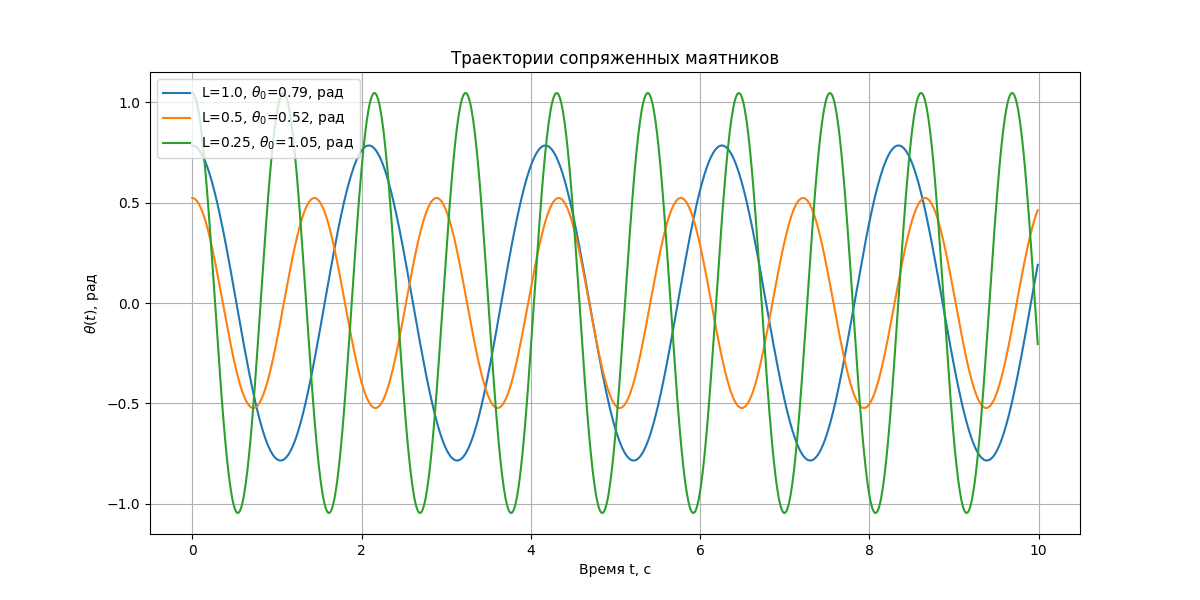

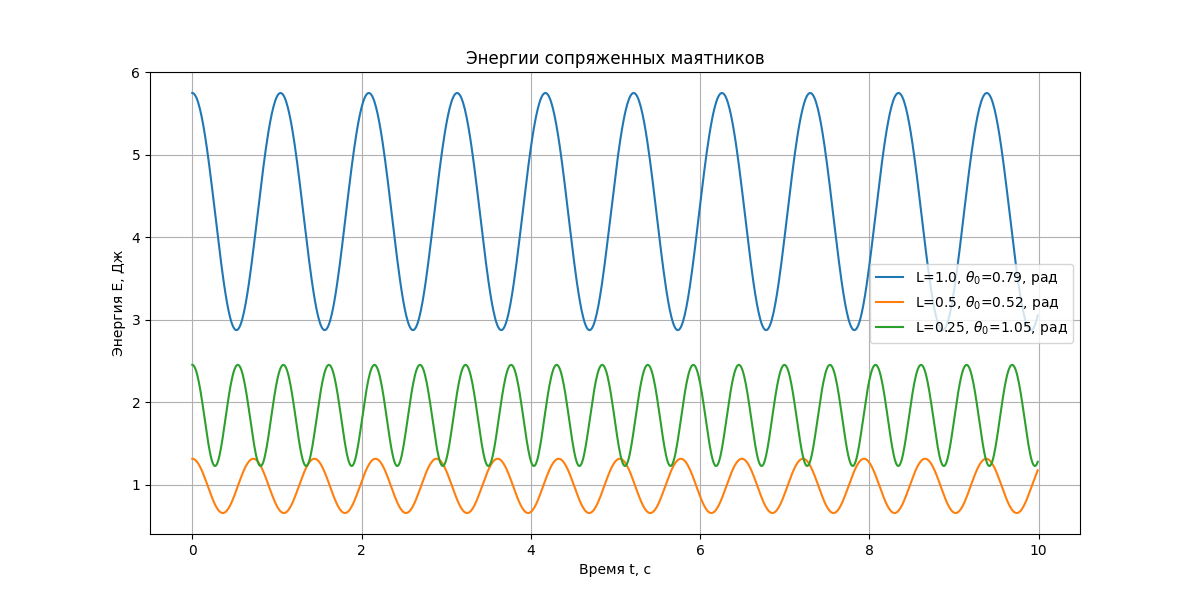

In [ ]:
colors = ['blue', 'red', 'green']
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 0.2)
ax.set_aspect('equal')
ax.grid()

lines = [ax.plot([], [], 'o-', lw=2, c=color)[0] for color in colors]
circles = [Circle((0, 0), 0.025, fc=color, ec='none') for color in colors]
for circle in circles:
    ax.add_patch(circle)

pivot = ax.plot(0, 0, 'o', markersize=6, color='black', markeredgecolor='none')[0]

def init():
    for line in lines:
        line.set_data([], [])
    for circle in circles:
        circle.center = (0, 0)
    return lines  + circles + [pivot]

def animate(t):
    for i, (length, theta0, color) in enumerate(zip(lengths, theta0s, colors)):
        omega = np.sqrt(g / length)
        theta = theta0 * np.cos(omega * t)
        x = length * np.sin(theta)
        y = -length * np.cos(theta)
        lines[i].set_data([0, x], [0, y])
        circles[i].center = (x, y) 
    return lines + circles +[pivot]

ani = FuncAnimation(fig, animate, frames=np.linspace(0, 20, 500),
                    init_func=init, blit=True, interval=20)

plt.title('Сопряженные маятники')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

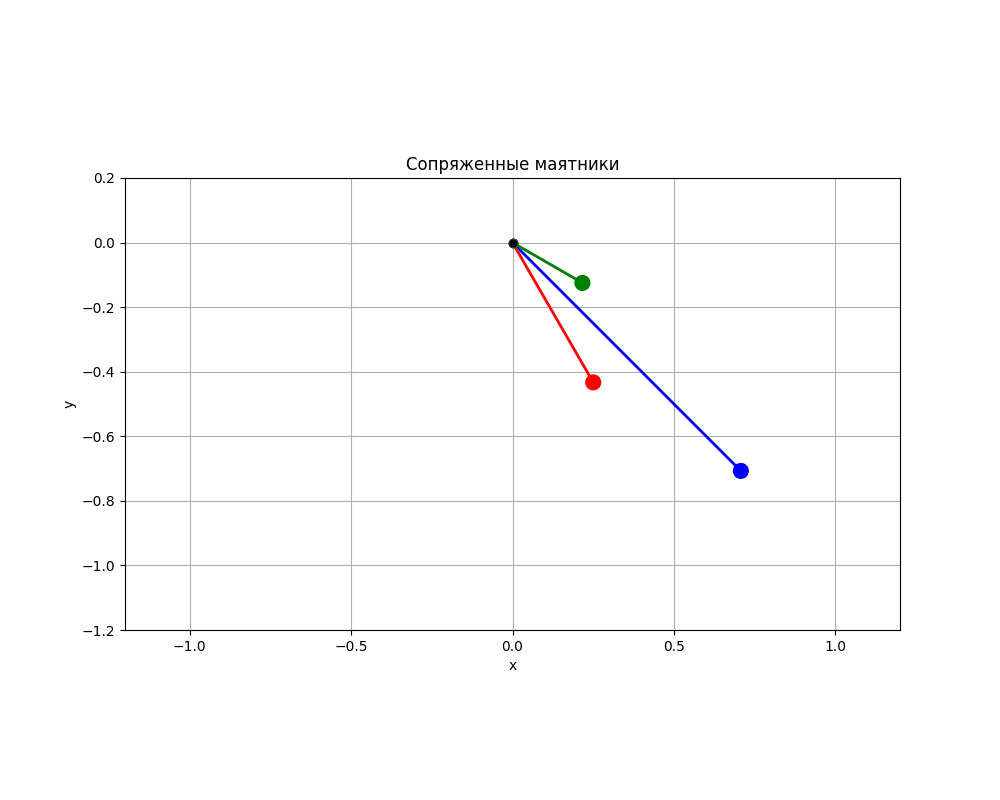